<div dir="rtl">

# نوت‌بوک ۲: کاهش ابعاد (Dimensionality Reduction) روی MNIST
## PCA، SVD، t-SNE و روش‌های مشابه — شرح، کد، مصورسازی و مقایسه

هر تصویر MNIST یک نقطه در فضای **۷۸۴ بعدی** است. کار با داده‌های پربعد مشکلاتی دارد که به آن **نفرین ابعاد (Curse of Dimensionality)** می‌گویند:
- حجم محاسبات و حافظه زیاد می‌شود؛
- فاصله‌ها در ابعاد بالا معنای خود را از دست می‌دهند (همه نقاط تقریباً به یک فاصله از هم هستند)؛
- مصورسازی مستقیم غیرممکن است؛
- خطر بیش‌برازش بیشتر می‌شود.

**کاهش ابعاد** یعنی پیدا کردن نمایشی با ابعاد کمتر که اطلاعات مهم داده را حفظ کند.

### دسته‌بندی روش‌ها
| دسته | روش‌ها | ایده |
|---|---|---|
| **خطی، بدون نظارت** | PCA، TruncatedSVD، NMF، ICA | تصویر کردن داده روی یک زیرفضای خطی |
| **خطی، با نظارت** | LDA | یافتن جهت‌هایی که کلاس‌ها را بیشتر از هم جدا می‌کنند |
| **غیرخطی (کرنلی)** | Kernel PCA | PCA در یک فضای ویژگی غیرخطی |
| **یادگیری منیفلد (Manifold Learning)** | Isomap، LLE، Spectral Embedding، MDS، **t-SNE**، (UMAP) | فرض: داده روی یک «منیفلد» کم‌بعد در فضای پربعد قرار دارد |

### فهرست مطالب
1. آماده‌سازی داده
2. PCA (تحلیل مؤلفه‌های اصلی)
3. SVD و TruncatedSVD
4. مقایسه سرعت PCA، Randomized PCA، IncrementalPCA و TruncatedSVD
5. Kernel PCA
6. LDA (کاهش ابعاد با نظارت)
7. NMF و ICA (مقایسه مؤلفه‌ها)
8. t-SNE
9. سایر روش‌های Manifold Learning: Isomap، LLE، Spectral، MDS (و UMAP)
10. مقایسه کمّی همه روش‌ها
11. کاهش ابعاد به عنوان پیش‌پردازش طبقه‌بندی
12. جمع‌بندی و جدول مقایسه نهایی

</div>

<div dir="rtl">

## ۱. وارد کردن کتابخانه‌ها و آماده‌سازی داده

- داده MNIST را مثل نوت‌بوک قبل بارگذاری و بر ۲۵۵ تقسیم می‌کنیم.
- روش‌های خطی (PCA و SVD) سریع‌اند و روی کل ۶۰۰۰۰ نمونه اجرا می‌شوند.
- روش‌های غیرخطی (مثل t-SNE، Isomap و MDS) پیچیدگی محاسباتی بالایی دارند ($O(n^2)$ یا بیشتر)، بنابراین روی **زیرمجموعه‌های طبقه‌بندی‌شده (stratified)** با ۲۰۰۰ یا ۵۰۰۰ نمونه اجرا می‌شوند.

</div>

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)
from scipy import sparse

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA, TruncatedSVD, IncrementalPCA, KernelPCA, NMF, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding, trustworthiness
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi': 100})

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(np.int64)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


def stratified_subset(X, y, n, seed=RANDOM_STATE):
    idx, _ = train_test_split(np.arange(len(y)), train_size=n, stratify=y, random_state=seed)
    return X[idx], y[idx]


X_5k, y_5k = stratified_subset(X_train, y_train, 5000)
X_2k, y_2k = stratified_subset(X_train, y_train, 2000)
print('Full train:', X_train.shape, '| subset 5k:', X_5k.shape, '| subset 2k:', X_2k.shape)

Full train: (60000, 784) | subset 5k: (5000, 784) | subset 2k: (2000, 784)


<div dir="rtl">

یک تابع کمکی برای رسم نمودار پراکندگی دوبعدی می‌نویسیم: هر نقطه یک تصویر است، رنگ آن رقم واقعی را نشان می‌دهد و عدد هر کلاس در **میانه** نقاط آن کلاس نوشته می‌شود.

> دقت کنید: روش‌های بدون نظارت **از برچسب‌ها استفاده نمی‌کنند**؛ رنگ‌آمیزی فقط برای ارزیابی بصری ماست.

</div>

In [2]:
def plot_embedding(Z, labels, title, ax=None, s=4, annotate=True):
    ax = ax if ax is not None else plt.gca()
    ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='tab10', s=s, alpha=0.7, vmin=0, vmax=9)
    if annotate:
        for d in range(10):
            mx, my = np.median(Z[labels == d], axis=0)
            ax.text(mx, my, str(d), fontsize=13, weight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='circle,pad=0.2', fc='white', ec='gray', alpha=0.85))
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return ax

<div dir="rtl">

## ۲. PCA — تحلیل مؤلفه‌های اصلی (Principal Component Analysis)

### ایده
PCA جهت‌هایی (مؤلفه‌هایی) در فضا پیدا می‌کند که **بیشترین واریانس** داده در آن جهت‌ها باشد. این جهت‌ها بر هم عمودند و به ترتیب واریانس مرتب می‌شوند.

### روش کار (گام به گام)
1. **مرکزی کردن داده:** $\tilde{X} = X - \bar{x}$
2. **ماتریس کوواریانس:** $C = \frac{1}{n-1}\tilde{X}^\top \tilde{X}$ (ابعاد ۷۸۴×۷۸۴)
3. **تجزیه ویژه:** $C v_i = \lambda_i v_i$؛ بردارهای ویژه $v_i$ همان **مؤلفه‌های اصلی** و مقادیر ویژه $\lambda_i$ **واریانس** در آن جهت هستند.
4. **تصویر کردن:** $Z = \tilde{X} V_k$ که $V_k$ شامل $k$ بردار ویژه اول است.
5. **بازسازی:** $\hat{X} = Z V_k^\top + \bar{x}$

**نسبت واریانس توضیح داده‌شده** برای مؤلفه $i$:
$$\text{EVR}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

### ویژگی‌ها
- خطی، سریع، قطعی (deterministic)، قابل تفسیر
- برای داده‌های جدید `transform` دارد
- فقط ساختارهای **خطی** را می‌بیند

### ۲-۱. واریانس توضیح داده‌شده (Scree Plot)
PCA کامل (۷۸۴ مؤلفه) را روی ۶۰۰۰۰ نمونه برازش می‌دهیم.

</div>

PCA fitted on (60000, 784) in 0.7 s
 50% of variance  ->   11 components  (compression x71.3)
 80% of variance  ->   44 components  (compression x17.8)
 90% of variance  ->   87 components  (compression x9.0)
 95% of variance  ->  154 components  (compression x5.1)
 99% of variance  ->  331 components  (compression x2.4)


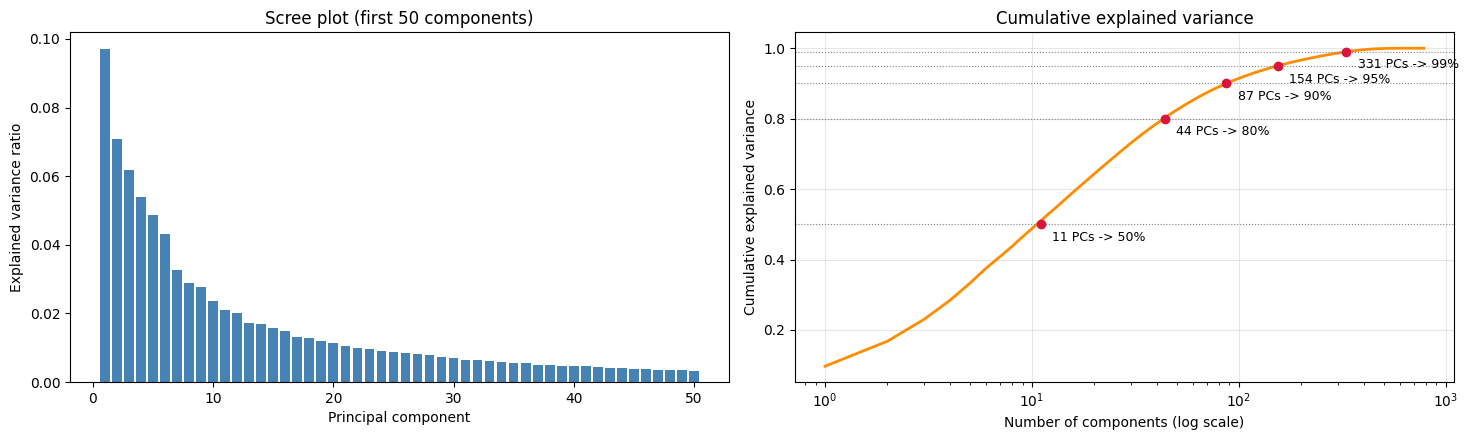

In [3]:
t0 = time.time()
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train)
print(f'PCA fitted on {X_train.shape} in {time.time() - t0:.1f} s')

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
thresholds = [0.5, 0.8, 0.9, 0.95, 0.99]
n_needed = {t: int(np.argmax(cum >= t)) + 1 for t in thresholds}
for t, n in n_needed.items():
    print(f'{int(t * 100):>3}% of variance  ->  {n:>3} components  (compression x{784 / n:.1f})')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(range(1, 51), evr[:50], color='steelblue')
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot (first 50 components)')

axes[1].plot(range(1, 785), cum, color='darkorange', lw=2)
for t, n in n_needed.items():
    axes[1].axhline(t, color='gray', ls=':', lw=0.8)
    axes[1].plot(n, t, 'o', color='crimson')
    axes[1].annotate(f'{n} PCs -> {int(t * 100)}%', (n, t), textcoords='offset points', xytext=(8, -12), fontsize=9)
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of components (log scale)'); axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:** با حدود ۱۵۰ مؤلفه (به جای ۷۸۴) حدود ۹۵٪ واریانس حفظ می‌شود؛ یعنی **فشرده‌سازی حدود ۵ برابر** با اتلاف کم. می‌توان به `PCA` مستقیماً یک عدد اعشاری داد: `PCA(n_components=0.95)` خودش تعداد مؤلفه لازم را انتخاب می‌کند.

### ۲-۲. مؤلفه‌های اصلی به شکل تصویر («Eigen-digits»)
هر مؤلفه اصلی یک بردار ۷۸۴تایی است و می‌توان آن را مثل یک تصویر ۲۸×۲۸ نمایش داد. هر تصویر ورودی ≈ **تصویر میانگین + ترکیب خطی این الگوها**.

</div>

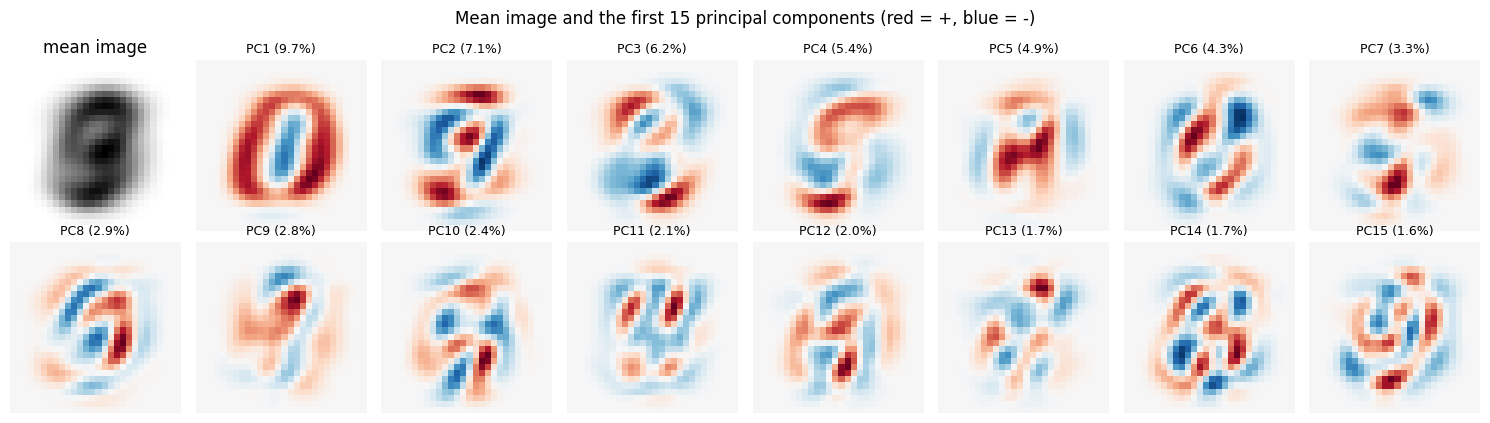

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(15, 4.3))
axes = axes.ravel()
axes[0].imshow(pca_full.mean_.reshape(28, 28), cmap='gray_r')
axes[0].set_title('mean image'); axes[0].axis('off')
for i in range(1, 16):
    comp = pca_full.components_[i - 1].reshape(28, 28)
    v = np.abs(comp).max()
    axes[i].imshow(comp, cmap='RdBu_r', vmin=-v, vmax=v)
    axes[i].set_title(f'PC{i} ({evr[i - 1] * 100:.1f}%)', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Mean image and the first 15 principal components (red = +, blue = -)')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۲-۳. نمایش داده در ۲ و ۳ بعد
داده ۵۰۰۰ نمونه‌ای را روی دو (و سه) مؤلفه اول تصویر می‌کنیم. دو مؤلفه اول فقط حدود ۱۷٪ واریانس را دارند، بنابراین انتظار جداسازی کامل کلاس‌ها را نداریم، اما ارقامی مثل **۰** و **۱** که ساختار کاملاً متفاوتی دارند، جدا می‌شوند.

</div>

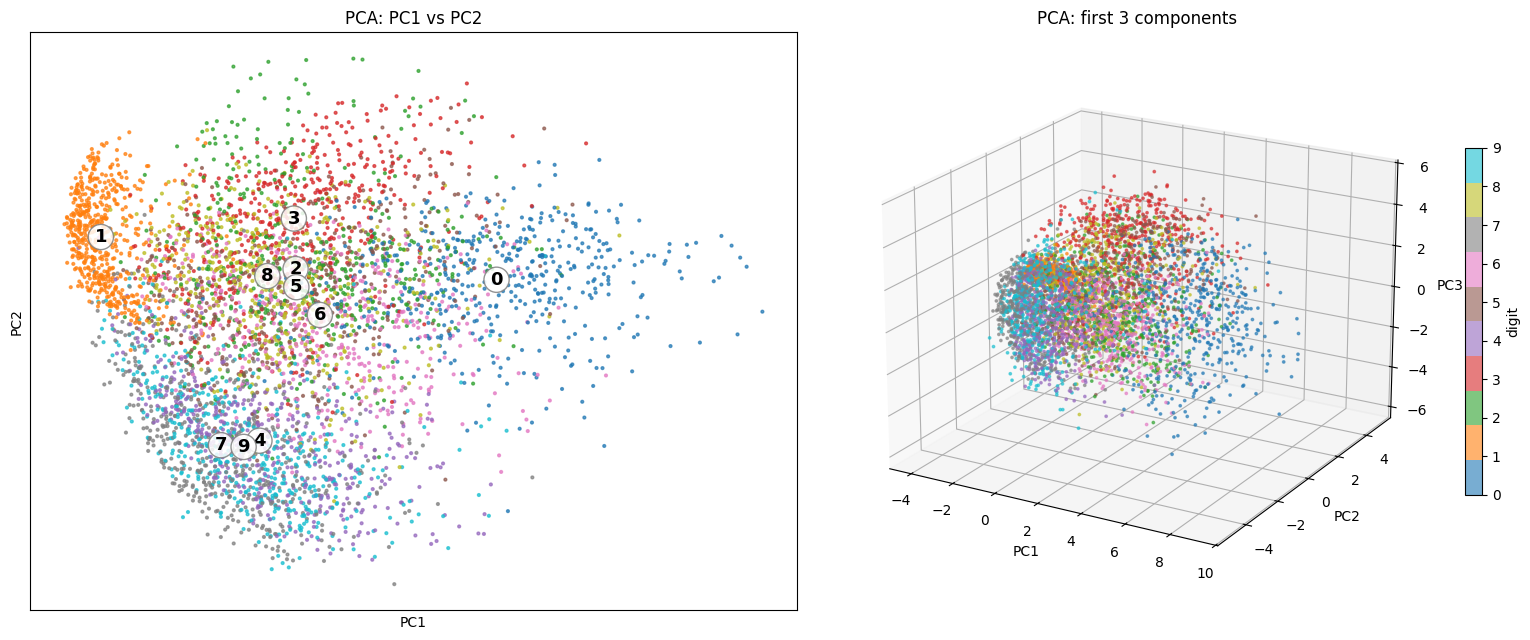

In [5]:
Z_pca = pca_full.transform(X_5k)[:, :3]

fig = plt.figure(figsize=(16, 6.5))
ax1 = fig.add_subplot(1, 2, 1)
plot_embedding(Z_pca[:, :2], y_5k, 'PCA: PC1 vs PC2', ax=ax1)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc = ax2.scatter(Z_pca[:, 0], Z_pca[:, 1], Z_pca[:, 2], c=y_5k, cmap='tab10', s=3, alpha=0.6)
ax2.set_title('PCA: first 3 components'); ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')
ax2.view_init(elev=20, azim=-60)
fig.colorbar(sc, ax=ax2, shrink=0.6, label='digit')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۲-۴. بازسازی تصویر با تعداد مؤلفه‌های مختلف
با نگه داشتن فقط $k$ مؤلفه و بازسازی $\hat{X} = Z_k V_k^\top + \bar{x}$ می‌بینیم چه مقدار اطلاعات حفظ شده است. همچنین **خطای بازسازی (MSE)** روی داده آزمون را بر حسب $k$ رسم می‌کنیم. (از مؤلفه‌های `pca_full` استفاده می‌کنیم، بنابراین نیازی به برازش دوباره نیست.)

</div>

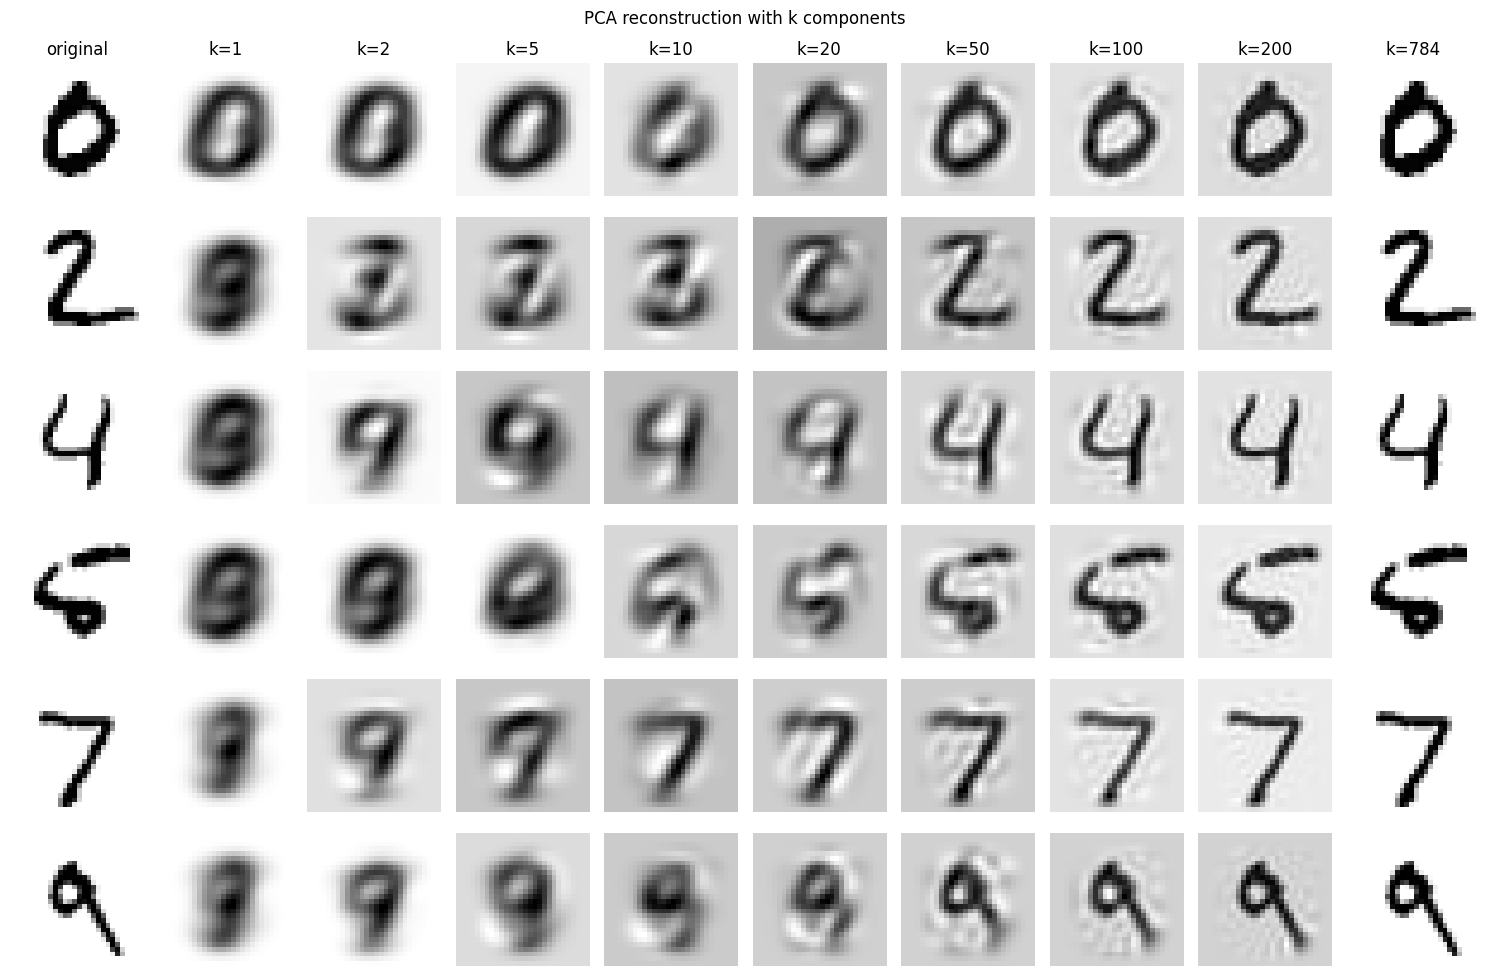

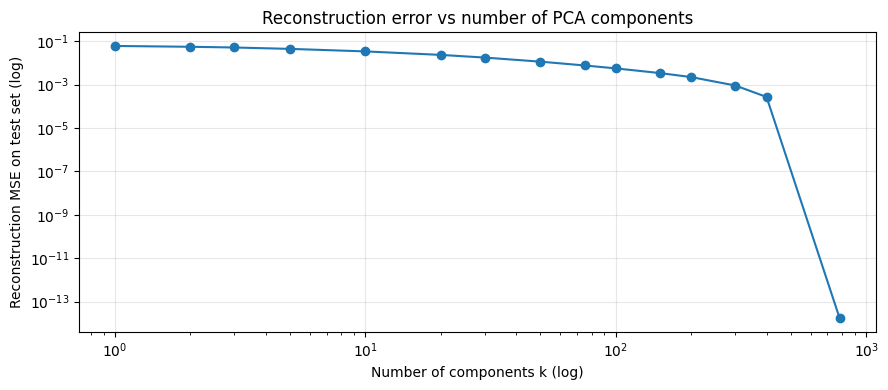

In [6]:
def pca_reconstruct(Xin, k, pca=pca_full):
    V = pca.components_[:k]
    return (Xin - pca.mean_) @ V.T @ V + pca.mean_

ks = [1, 2, 5, 10, 20, 50, 100, 200, 784]
sample_idx = [np.where(y_test == d)[0][0] for d in [0, 2, 4, 5, 7, 9]]

fig, axes = plt.subplots(len(sample_idx), len(ks) + 1, figsize=(15, 10))
for r, i in enumerate(sample_idx):
    axes[r, 0].imshow(X_test[i].reshape(28, 28), cmap='gray_r')
    for c, k in enumerate(ks, start=1):
        rec = pca_reconstruct(X_test[i:i + 1], k)
        axes[r, c].imshow(rec.reshape(28, 28), cmap='gray_r')
for c, t in enumerate(['original'] + [f'k={k}' for k in ks]):
    axes[0, c].set_title(t)
for ax in axes.ravel():
    ax.axis('off')
plt.suptitle('PCA reconstruction with k components')
plt.tight_layout()
plt.show()

k_range = [1, 2, 3, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 784]
mse = [np.mean((X_test - pca_reconstruct(X_test, k)) ** 2) for k in k_range]
plt.figure(figsize=(9, 4))
plt.plot(k_range, mse, 'o-')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Number of components k (log)'); plt.ylabel('Reconstruction MSE on test set (log)')
plt.title('Reconstruction error vs number of PCA components')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

## ۳. SVD — تجزیه مقدار منفرد (Singular Value Decomposition)

### ایده
هر ماتریس $X_{n \times d}$ را می‌توان به صورت زیر تجزیه کرد:
$$X = U \Sigma V^\top$$
- $U$ ($n \times r$): بردارهای منفرد چپ (متعامد)
- $\Sigma$: ماتریس قطری مقادیر منفرد $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$
- $V$ ($d \times r$): بردارهای منفرد راست (متعامد)

**SVD کوتاه‌شده (Truncated SVD)** فقط $k$ مقدار منفرد بزرگ را نگه می‌دارد: $X \approx U_k \Sigma_k V_k^\top$، که بهترین تقریب با رتبه $k$ است (قضیه Eckart–Young).

### رابطه PCA و SVD
**PCA همان SVD روی داده مرکزی‌شده است!** اگر $\tilde{X} = U\Sigma V^\top$ باشد:
- ستون‌های $V$ = مؤلفه‌های اصلی
- $\lambda_i = \frac{\sigma_i^2}{n-1}$ (واریانس هر مؤلفه)

در واقع `sklearn.decomposition.PCA` در داخل خودش از SVD استفاده می‌کند.

### تفاوت `TruncatedSVD` با `PCA`
| | `PCA` | `TruncatedSVD` |
|---|---|---|
| مرکزی کردن داده | بله | **خیر** |
| داده اسپارس (Sparse) | محدود | **کاملاً پشتیبانی می‌شود** (چون مرکزی کردن ماتریس اسپارس آن را چگال می‌کند) |
| کاربرد رایج | داده‌های چگال عددی | متن (TF-IDF) و **LSA**، سیستم‌های توصیه‌گر |
| مؤلفه اول | جهت بیشترین واریانس | معمولاً جهت **میانگین** داده |

</div>

<div dir="rtl">

### ۳-۱. اثبات عملی: PCA = SVD روی داده مرکزی‌شده
با `numpy.linalg.svd` روی داده مرکزی‌شده، مؤلفه‌ها را با خروجی `PCA` مقایسه می‌کنیم. (علامت بردارها ممکن است برعکس باشد، پس قدرمطلق ضرب داخلی را می‌گیریم؛ مقدار ۱ یعنی بردارها یکسان‌اند.)

</div>

In [7]:
Xc = X_5k - X_5k.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
pca_5k = PCA(n_components=10, svd_solver='full').fit(X_5k)

cosines = np.abs(np.sum(Vt[:10] * pca_5k.components_, axis=1))
var_from_svd = S[:10] ** 2 / (len(X_5k) - 1)
print('|cos(angle)| between SVD and PCA components :', np.round(cosines, 6))
print('variance from SVD  (sigma^2 / (n-1))        :', np.round(var_from_svd[:5], 5))
print('PCA explained_variance_                     :', np.round(pca_5k.explained_variance_[:5], 5))

|cos(angle)| between SVD and PCA components : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
variance from SVD  (sigma^2 / (n-1))        : [5.24505 3.7079  3.18331 2.89694 2.57789]
PCA explained_variance_                     : [5.24505 3.7079  3.18331 2.89694 2.57789]


<div dir="rtl">

### ۳-۲. `TruncatedSVD` روی MNIST و مقایسه با PCA

</div>

TruncatedSVD(50) fitted in 1.4 s


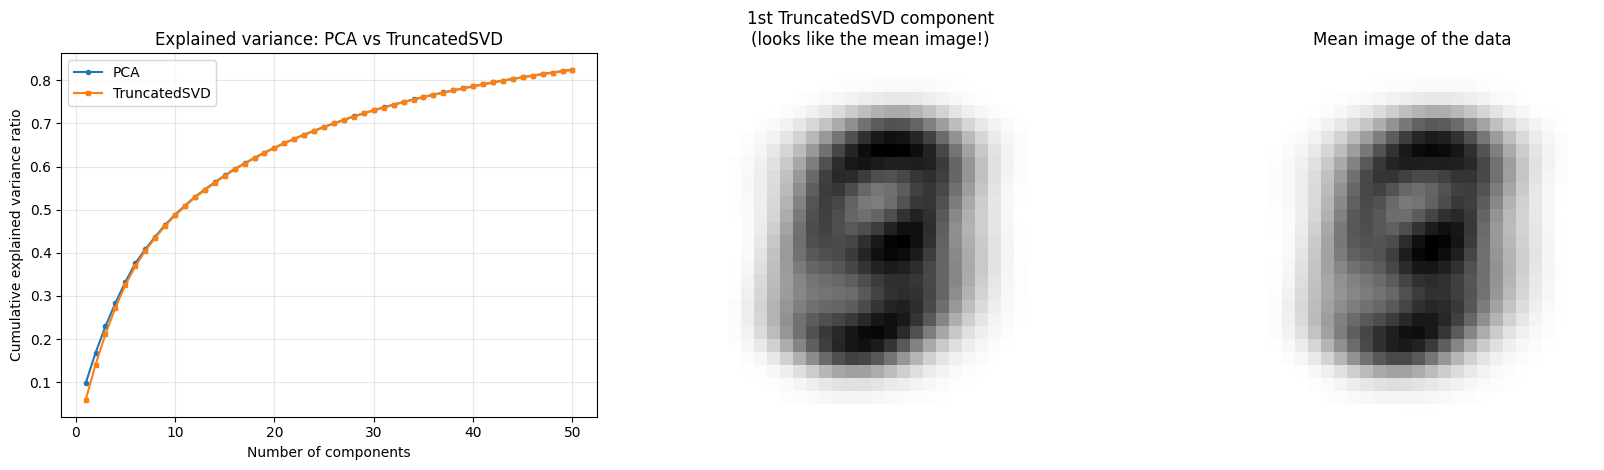

Correlation between 1st SVD component and the mean image: 0.9987


In [8]:
t0 = time.time()
svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit(X_train)
print(f'TruncatedSVD(50) fitted in {time.time() - t0:.1f} s')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].plot(np.arange(1, 51), np.cumsum(pca_full.explained_variance_ratio_[:50]), 'o-', ms=3, label='PCA')
axes[0].plot(np.arange(1, 51), np.cumsum(svd.explained_variance_ratio_), 's-', ms=3, label='TruncatedSVD')
axes[0].set_xlabel('Number of components'); axes[0].set_ylabel('Cumulative explained variance ratio')
axes[0].set_title('Explained variance: PCA vs TruncatedSVD'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].imshow(svd.components_[0].reshape(28, 28), cmap='gray_r')
axes[1].set_title('1st TruncatedSVD component\n(looks like the mean image!)'); axes[1].axis('off')
axes[2].imshow(pca_full.mean_.reshape(28, 28), cmap='gray_r')
axes[2].set_title('Mean image of the data'); axes[2].axis('off')
plt.tight_layout()
plt.show()

corr = np.corrcoef(svd.components_[0], pca_full.mean_)[0, 1]
print(f'Correlation between 1st SVD component and the mean image: {abs(corr):.4f}')

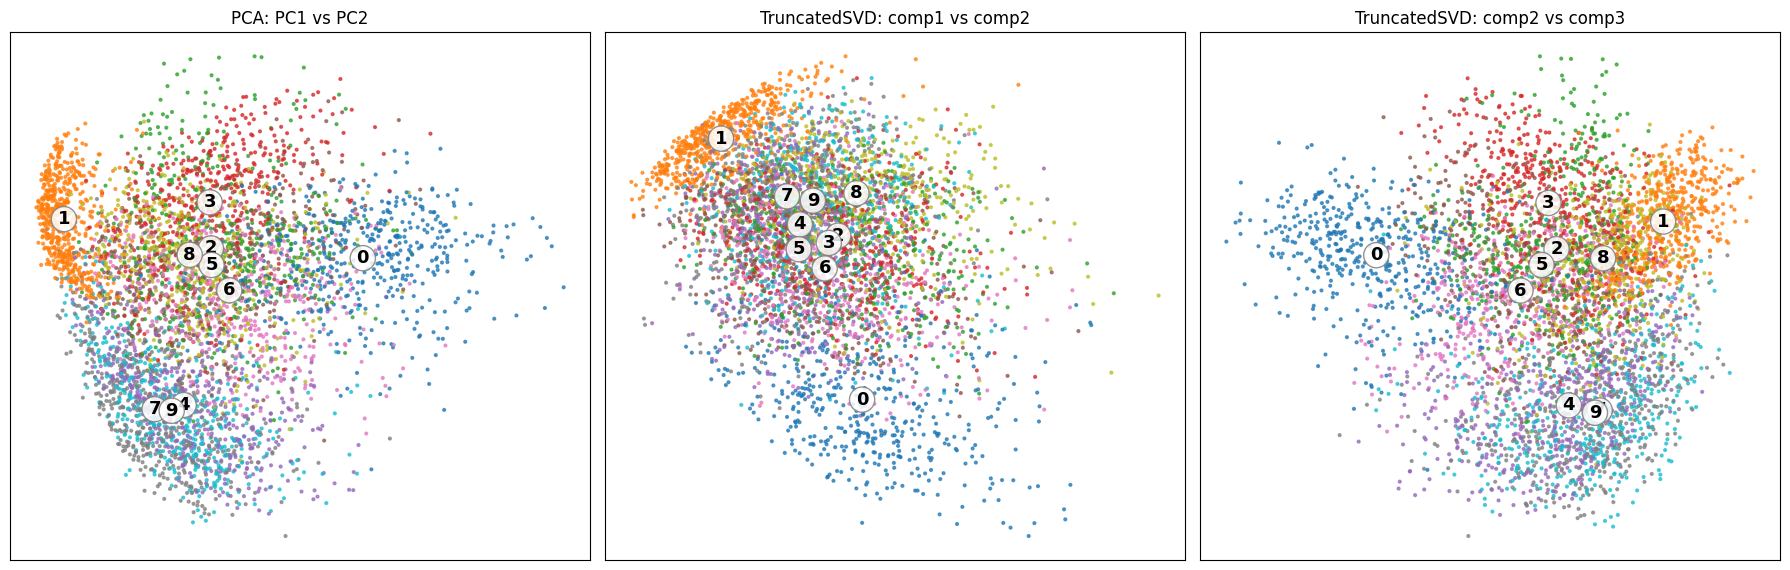

In [9]:
Z_svd = svd.transform(X_5k)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
plot_embedding(Z_pca[:, :2], y_5k, 'PCA: PC1 vs PC2', ax=axes[0])
plot_embedding(Z_svd[:, :2], y_5k, 'TruncatedSVD: comp1 vs comp2', ax=axes[1])
plot_embedding(Z_svd[:, 1:3], y_5k, 'TruncatedSVD: comp2 vs comp3', ax=axes[2])
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:** چون `TruncatedSVD` داده را مرکزی نمی‌کند، مؤلفه اول آن تقریباً همان «جهت میانگین» است و بیشتر **روشنایی کلی** تصویر را اندازه می‌گیرد، نه تفاوت بین ارقام. به همین دلیل نمودار (comp2, comp3) در SVD شبیه (PC1, PC2) در PCA است.

### ۳-۳. کار با ماتریس اسپارس
حدود ۸۰٪ پیکسل‌های MNIST صفر هستند. `TruncatedSVD` مستقیماً روی ماتریس اسپارس `scipy.sparse` کار می‌کند بدون اینکه آن را چگال کند. این برای داده‌های متنی (با میلیون‌ها ستون) حیاتی است.

</div>

In [10]:
X_sparse = sparse.csr_matrix(X_train)
density = X_sparse.nnz / np.prod(X_sparse.shape)
dense_mb = X_train.nbytes / 1e6
sparse_mb = (X_sparse.data.nbytes + X_sparse.indices.nbytes + X_sparse.indptr.nbytes) / 1e6
print(f'Density: {density:.3f}  |  dense: {dense_mb:.0f} MB  |  sparse CSR: {sparse_mb:.0f} MB')

t0 = time.time()
Z_sp = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(X_sparse)
print(f'TruncatedSVD on sparse input: {Z_sp.shape} in {time.time() - t0:.1f} s')

Density: 0.191  |  dense: 188 MB  |  sparse CSR: 72 MB


TruncatedSVD on sparse input: (60000, 50) in 4.7 s


<div dir="rtl">

## ۴. مقایسه سرعت پیاده‌سازی‌های مختلف PCA/SVD

| روش | توضیح |
|---|---|
| `PCA(svd_solver='full')` | SVD کامل دقیق (LAPACK) |
| `PCA(svd_solver='randomized')` | **SVD تصادفی** (Halko و همکاران): تقریب بسیار سریع وقتی $k \ll d$ |
| `IncrementalPCA` | داده را **دسته به دسته** پردازش می‌کند؛ برای داده‌ای که در حافظه جا نمی‌شود |
| `TruncatedSVD` | SVD تصادفی بدون مرکزی کردن |

هر چهار روش را برای استخراج ۵۰ مؤلفه روی ۶۰۰۰۰ نمونه اجرا و زمان و واریانس حفظ‌شده را مقایسه می‌کنیم.

</div>

,time_s,explained_var_50
method,,
PCA full,5.3465,0.8246
PCA randomized,1.9137,0.8246
IncrementalPCA,19.8344,0.8243
TruncatedSVD,1.6114,0.8244


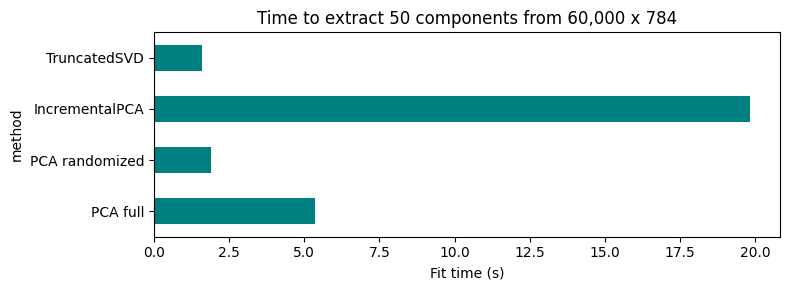

In [11]:
speed_methods = {
    'PCA full': PCA(n_components=50, svd_solver='full'),
    'PCA randomized': PCA(n_components=50, svd_solver='randomized', random_state=RANDOM_STATE),
    'IncrementalPCA': IncrementalPCA(n_components=50, batch_size=5000),
    'TruncatedSVD': TruncatedSVD(n_components=50, random_state=RANDOM_STATE),
}
speed_rows = []
for name, m in speed_methods.items():
    t0 = time.time(); m.fit(X_train); dt = time.time() - t0
    speed_rows.append({'method': name, 'time_s': dt, 'explained_var_50': m.explained_variance_ratio_.sum()})
speed_df = pd.DataFrame(speed_rows).set_index('method')
display(speed_df.round(4))

ax = speed_df['time_s'].plot.barh(figsize=(8, 3), color='teal')
ax.set_xlabel('Fit time (s)'); ax.set_title('Time to extract 50 components from 60,000 x 784')
plt.tight_layout(); plt.show()

<div dir="rtl">

## ۵. Kernel PCA — PCA غیرخطی

### ایده
داده را با یک نگاشت غیرخطی $\phi(x)$ به فضایی با ابعاد بالاتر (حتی بی‌نهایت) می‌بریم و آنجا PCA می‌زنیم. با **ترفند کرنل (Kernel Trick)** نیازی به محاسبه صریح $\phi$ نیست؛ فقط ماتریس کرنل $K_{ij} = k(x_i, x_j)$ لازم است، مثلاً کرنل RBF:
$$k(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$$

سپس تجزیه ویژه روی ماتریس کرنل مرکزی‌شده ($n \times n$) انجام می‌شود.

### نکات
- حافظه و زمان از مرتبه $O(n^2)$ و $O(n^3)$ ← فقط برای چند هزار نمونه عملی است.
- انتخاب کرنل و `gamma` بسیار مهم است.
- `fit_inverse_transform=True` امکان بازسازی تقریبی (pre-image) را می‌دهد.

روی ۲۰۰۰ نمونه، کرنل خطی (معادل PCA) را با دو مقدار `gamma` در کرنل RBF مقایسه می‌کنیم.

</div>

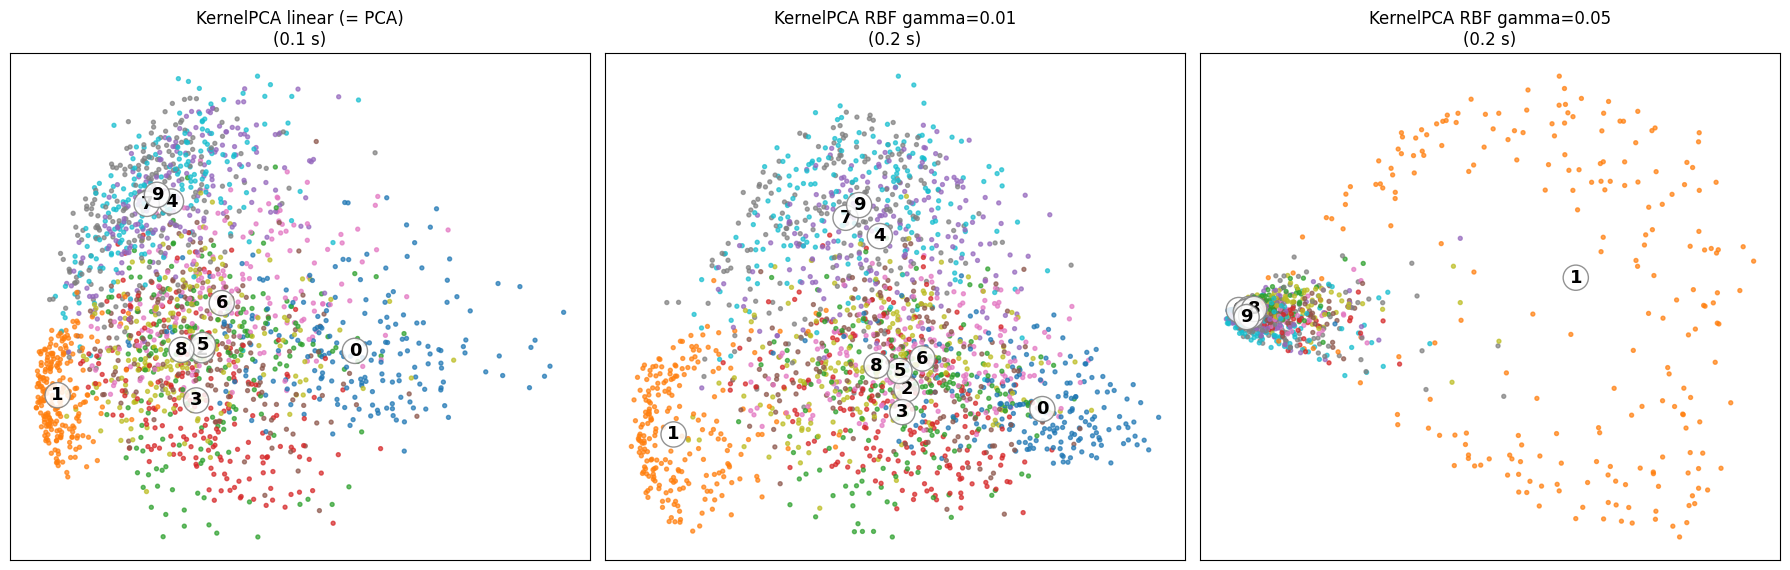

In [12]:
kpca_configs = {'KernelPCA linear (= PCA)': dict(kernel='linear'),
                'KernelPCA RBF gamma=0.01': dict(kernel='rbf', gamma=0.01),
                'KernelPCA RBF gamma=0.05': dict(kernel='rbf', gamma=0.05)}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
for ax, (name, kw) in zip(axes, kpca_configs.items()):
    t0 = time.time()
    Z = KernelPCA(n_components=2, random_state=RANDOM_STATE, **kw).fit_transform(X_2k)
    plot_embedding(Z, y_2k, f'{name}\n({time.time() - t0:.1f} s)', ax=ax, s=8)
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:** با کرنل RBF و `gamma` مناسب، ساختار محلی بهتر حفظ می‌شود؛ اما اگر `gamma` خیلی بزرگ باشد، کرنل فقط همسایه‌های خیلی نزدیک را «می‌بیند» و ساختار کلی از بین می‌رود. کرنل خطی دقیقاً همان PCA را می‌دهد.

</div>

<div dir="rtl">

## ۶. LDA — تحلیل تفکیک خطی (Linear Discriminant Analysis)

### ایده
برخلاف PCA که به برچسب‌ها توجهی ندارد، **LDA یک روش با نظارت** است: جهت‌هایی را پیدا می‌کند که
- فاصله بین **میانگین کلاس‌ها** بیشینه شود ($S_B$: پراکندگی بین کلاسی)
- پراکندگی **درون هر کلاس** کمینه شود ($S_W$: پراکندگی درون کلاسی)

$$J(w) = \frac{w^\top S_B\, w}{w^\top S_W\, w}$$

حداکثر تعداد مؤلفه‌ها **$C - 1$** است (برای ۱۰ کلاس ← ۹ مؤلفه).

### مقایسه با PCA
- PCA: «داده کجا بیشترین تغییرات را دارد؟»
- LDA: «در کدام جهت کلاس‌ها بهتر از هم جدا می‌شوند؟»

چون LDA از برچسب‌ها استفاده می‌کند، طبیعتاً جداسازی بهتری نشان می‌دهد؛ اما این یک **مقایسه ناعادلانه** با روش‌های بدون نظارت است. LDA را روی ۶۰۰۰۰ نمونه آموزش می‌دهیم و ۵۰۰۰ نمونه را نمایش می‌دهیم.

</div>

LDA fitted in 8.0 s
LDA used directly as a classifier -> test accuracy: 0.8730


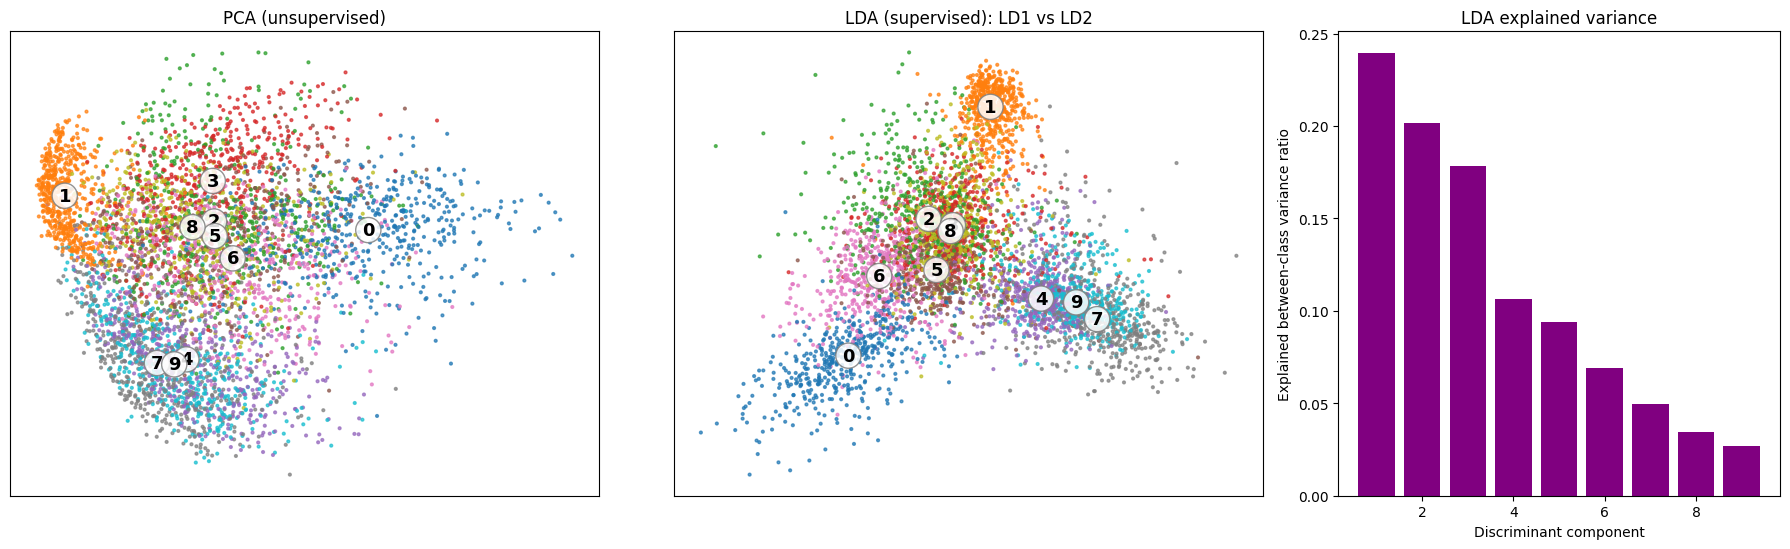

In [13]:
t0 = time.time()
lda = LinearDiscriminantAnalysis(n_components=9).fit(X_train, y_train)
print(f'LDA fitted in {time.time() - t0:.1f} s')
print(f'LDA used directly as a classifier -> test accuracy: {lda.score(X_test, y_test):.4f}')

Z_lda = lda.transform(X_5k)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), gridspec_kw={'width_ratios': [1.2, 1.2, 0.9]})
plot_embedding(Z_pca[:, :2], y_5k, 'PCA (unsupervised)', ax=axes[0])
plot_embedding(Z_lda[:, :2], y_5k, 'LDA (supervised): LD1 vs LD2', ax=axes[1])
axes[2].bar(range(1, 10), lda.explained_variance_ratio_, color='purple')
axes[2].set_xlabel('Discriminant component'); axes[2].set_ylabel('Explained between-class variance ratio')
axes[2].set_title('LDA explained variance')
plt.tight_layout()
plt.show()

<div dir="rtl">

## ۷. NMF و ICA — دو تجزیه خطی دیگر

### NMF (Non-negative Matrix Factorization)
داده نامنفی $X$ را به دو ماتریس **نامنفی** تجزیه می‌کند: $X \approx W H$ با $W, H \ge 0$.
چون همه ضرایب مثبت‌اند، هر تصویر **جمع** چند جزء است (هیچ جزئی کم نمی‌شود) ← مؤلفه‌ها **«قطعه‌ای» (parts-based)** و قابل تفسیرتر می‌شوند (مثلاً تکه‌هایی از خطوط ارقام).
کاربرد: مدل‌سازی موضوعی متن (Topic Modeling)، پردازش تصویر، بیوانفورماتیک.

### ICA (Independent Component Analysis)
مؤلفه‌هایی پیدا می‌کند که از نظر آماری **مستقل** باشند (نه فقط ناهمبسته مثل PCA). کاربرد کلاسیک: **جداسازی منابع** (مثل مسئله مهمانی کوکتل و جدا کردن صداها، یا سیگنال‌های EEG).

### مقایسه بصری مؤلفه‌ها
۱۶ مؤلفه از هر روش را روی ۱۰۰۰۰ نمونه آموزش می‌دهیم و به شکل تصویر نمایش می‌دهیم:
- **PCA:** الگوهای سراسری با مقادیر مثبت و منفی
- **NMF:** قطعات محلی و نامنفی
- **ICA:** الگوهایی که از نظر آماری مستقل‌اند (با مقادیر مثبت و منفی)

</div>

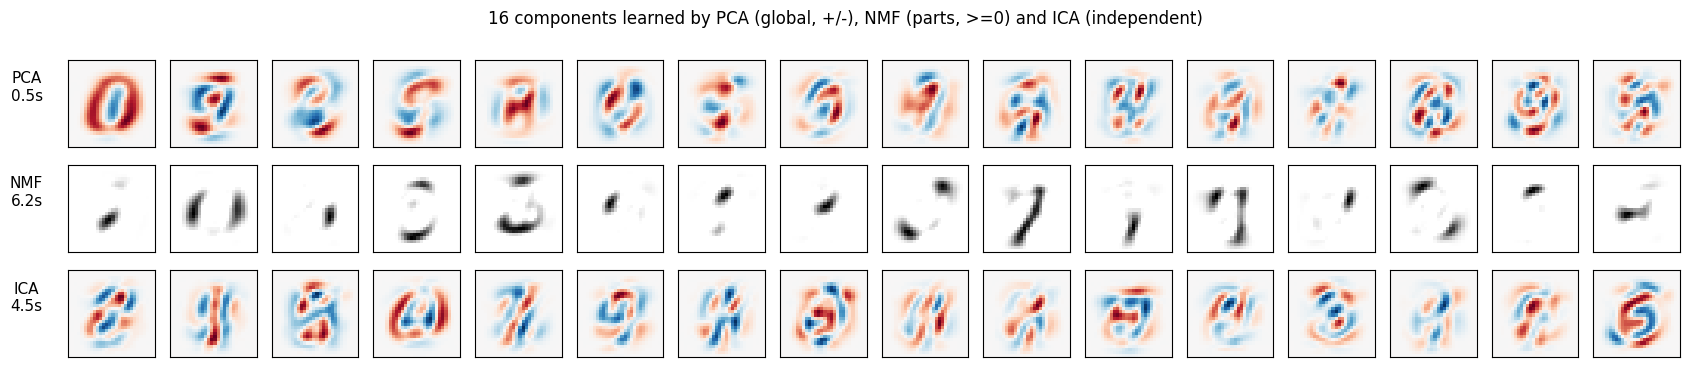

NMF reconstruction error (Frobenius): 509.91


In [14]:
X_10k, y_10k = stratified_subset(X_train, y_train, 10000)
n_comp = 16
t0 = time.time(); pca16 = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(X_10k); t_pca = time.time() - t0
t0 = time.time(); nmf16 = NMF(n_components=n_comp, init='nndsvda', max_iter=400, random_state=RANDOM_STATE).fit(X_10k); t_nmf = time.time() - t0
t0 = time.time(); ica16 = FastICA(n_components=n_comp, whiten='unit-variance', max_iter=500, random_state=RANDOM_STATE).fit(X_10k); t_ica = time.time() - t0

rows = [('PCA', pca16.components_, 'RdBu_r', t_pca), ('NMF', nmf16.components_, 'gray_r', t_nmf),
        ('ICA', ica16.components_, 'RdBu_r', t_ica)]
fig, axes = plt.subplots(3, n_comp, figsize=(17, 3.8))
for r, (name, comps, cmap, dt) in enumerate(rows):
    for c in range(n_comp):
        img = comps[c].reshape(28, 28)
        if cmap == 'RdBu_r':
            v = np.abs(img).max(); axes[r, c].imshow(img, cmap=cmap, vmin=-v, vmax=v)
        else:
            axes[r, c].imshow(img, cmap=cmap)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(f'{name}\n{dt:.1f}s', rotation=0, labelpad=30, fontsize=11)
plt.suptitle('16 components learned by PCA (global, +/-), NMF (parts, >=0) and ICA (independent)')
plt.tight_layout()
plt.show()

print(f'NMF reconstruction error (Frobenius): {nmf16.reconstruction_err_:.2f}')

<div dir="rtl">

## ۸. t-SNE (t-distributed Stochastic Neighbor Embedding)

t-SNE محبوب‌ترین روش برای **مصورسازی** داده‌های پربعد است.

### روش کار
1. **در فضای اصلی:** برای هر جفت نقطه، احتمال همسایگی با یک توزیع گاوسی حساب می‌شود:
$$p_{j|i} = \frac{\exp(-\lVert x_i - x_j \rVert^2 / 2\sigma_i^2)}{\sum_{k \ne i} \exp(-\lVert x_i - x_k \rVert^2 / 2\sigma_i^2)}, \qquad p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$
   پهنای $\sigma_i$ برای هر نقطه طوری تنظیم می‌شود که **Perplexity** (تقریباً «تعداد مؤثر همسایه‌ها») برابر مقدار دلخواه شود.
2. **در فضای کم‌بعد:** شباهت‌ها با توزیع **t-Student با یک درجه آزادی** (دنباله‌پهن) حساب می‌شوند:
$$q_{ij} = \frac{(1 + \lVert z_i - z_j \rVert^2)^{-1}}{\sum_{k \ne l} (1 + \lVert z_k - z_l \rVert^2)^{-1}}$$
   دنباله پهن توزیع t اجازه می‌دهد نقاط غیرهمسایه دور از هم قرار بگیرند و مشکل «ازدحام» (Crowding Problem) حل شود.
3. **بهینه‌سازی:** مختصات $z$ با گرادیان کاهشی طوری تنظیم می‌شود که **واگرایی KL** کمینه شود:
$$KL(P \Vert Q) = \sum_{i \ne j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

### نکات مهم و هشدارها
- t-SNE **ساختار محلی** (همسایگی‌ها) را خیلی خوب حفظ می‌کند؛ اما **اندازه خوشه‌ها و فاصله بین خوشه‌ها معنای دقیقی ندارند.**
- **تصادفی** است؛ اجراهای مختلف نتایج متفاوت می‌دهند (`random_state` را ثابت کنید).
- متد `transform` ندارد؛ یعنی نمی‌توان داده جدید را روی نقشه موجود برد ← برای **پیش‌پردازش مدل** مناسب نیست، فقط برای مصورسازی.
- کند است؛ پیاده‌سازی Barnes-Hut پیچیدگی $O(n \log n)$ دارد.
- **توصیه رایج:** ابتدا با PCA ابعاد را به حدود ۵۰ کاهش دهید، سپس t-SNE بزنید (سریع‌تر و کم‌نویزتر).

</div>

t-SNE on 5000 samples: 30.0 s,  final KL divergence = 1.506


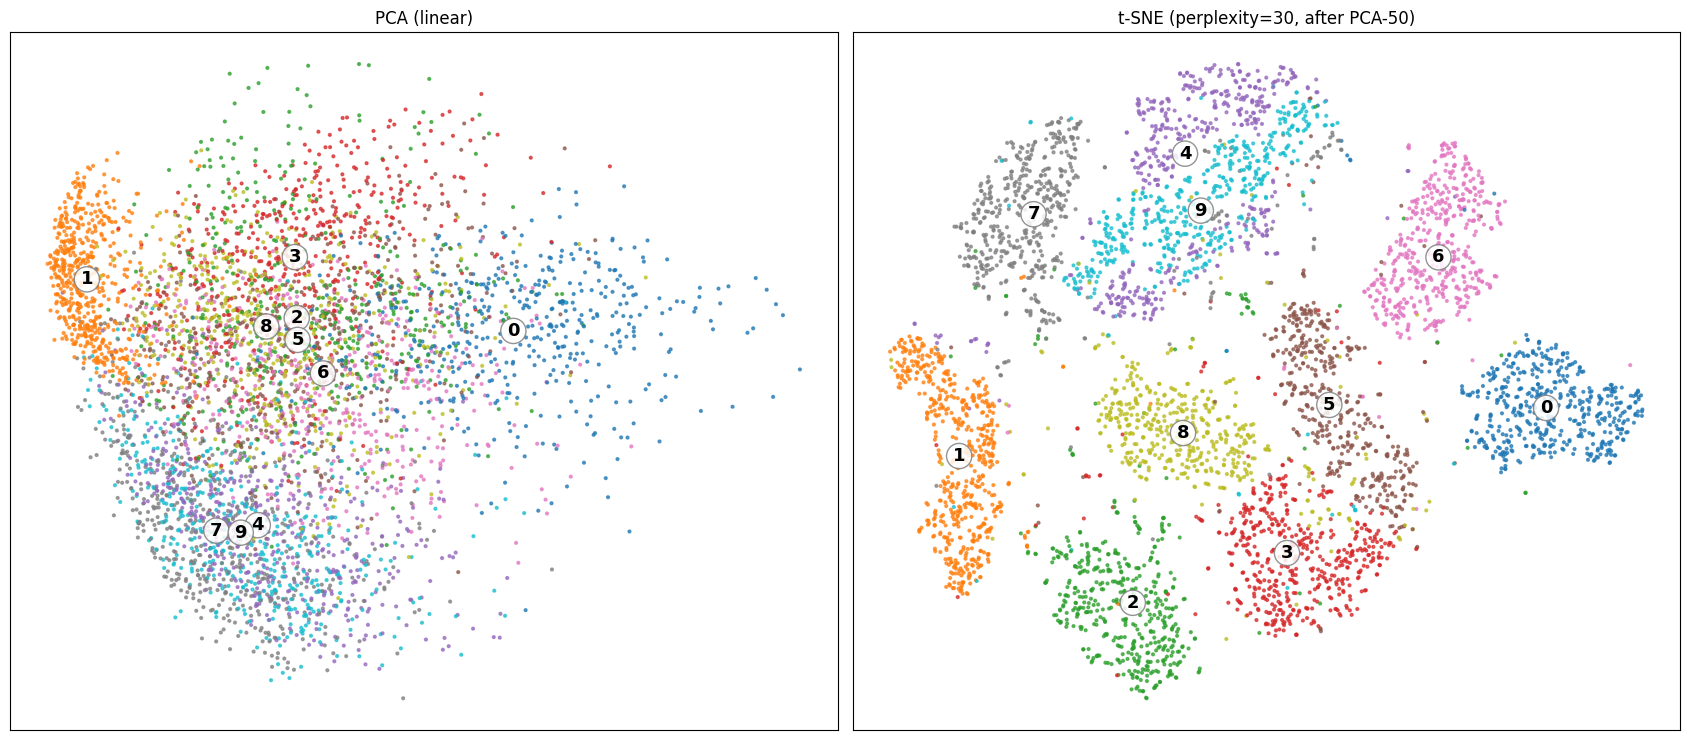

In [15]:
pca50_5k = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_5k)

t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
            random_state=RANDOM_STATE, n_jobs=-1)
Z_tsne = tsne.fit_transform(pca50_5k)
print(f't-SNE on 5000 samples: {time.time() - t0:.1f} s,  final KL divergence = {tsne.kl_divergence_:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
plot_embedding(Z_pca[:, :2], y_5k, 'PCA (linear)', ax=axes[0])
plot_embedding(Z_tsne, y_5k, 't-SNE (perplexity=30, after PCA-50)', ax=axes[1])
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:** تفاوت چشمگیر است! t-SNE ده خوشه تقریباً جدا از هم ساخته است، در حالی که PCA خطی ارقام را روی هم انداخته بود. خوشه‌های نزدیک به هم (مثلاً ۴، ۷ و ۹ یا ۳، ۵ و ۸) همان ارقامی هستند که شبیه یکدیگرند.

### ۸-۱. نمایش تصاویر روی نقشه t-SNE
برای شهود بیشتر، تصویر کوچک چند نمونه را در محل نقطه آن‌ها روی نقشه می‌گذاریم.

</div>

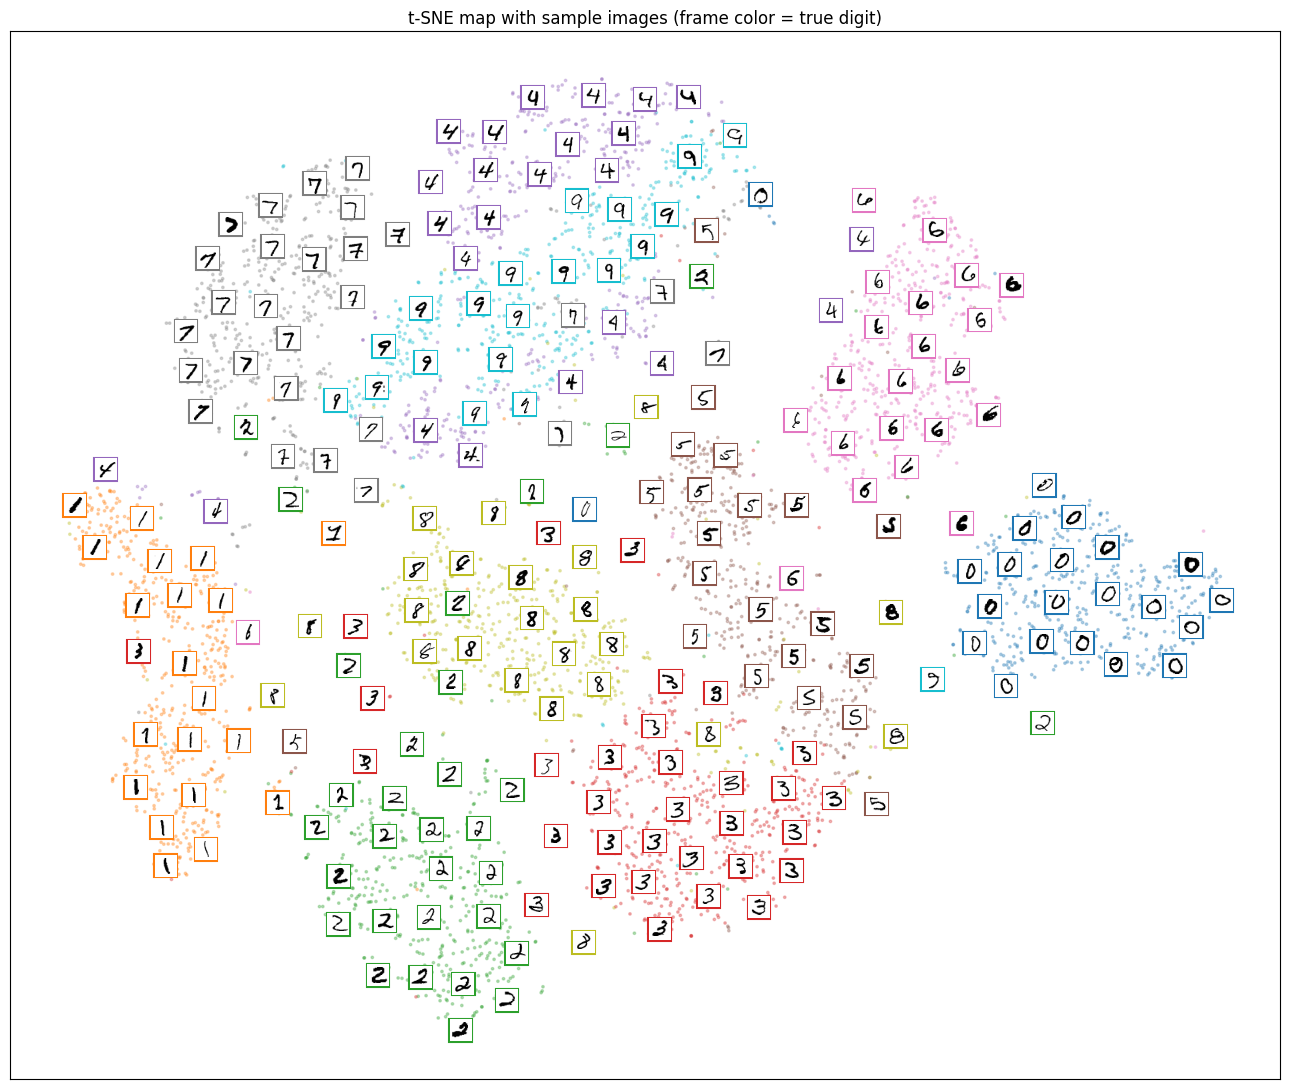

In [16]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(13, 11))
ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=y_5k, cmap='tab10', s=3, alpha=0.3)
shown = np.empty((0, 2))
min_dist = (Z_tsne.max() - Z_tsne.min()) * 0.035
for i in np.random.permutation(len(Z_tsne)):
    if len(shown) and np.min(np.sum((shown - Z_tsne[i]) ** 2, axis=1)) < min_dist ** 2:
        continue                                          # skip images that would overlap
    shown = np.vstack([shown, Z_tsne[i]])
    ab = AnnotationBbox(OffsetImage(X_5k[i].reshape(28, 28), cmap='gray_r', zoom=0.55),
                        Z_tsne[i], frameon=True, pad=0.05,
                        bboxprops=dict(edgecolor=plt.cm.tab10(y_5k[i]), lw=1.5))
    ax.add_artist(ab)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('t-SNE map with sample images (frame color = true digit)')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۸-۲. اثر Perplexity
Perplexity تعادل بین توجه به **ساختار محلی** و **ساختار کلی** را کنترل می‌کند:
- مقدار کم (مثلاً ۵): فقط چند همسایه خیلی نزدیک ← خوشه‌های کوچک و پراکنده
- مقدار زیاد (مثلاً ۱۰۰): همسایگی بزرگ‌تر ← ساختار کلی‌تر و خوشه‌های فشرده‌تر
- مقادیر معمول: بین ۵ تا ۵۰

</div>

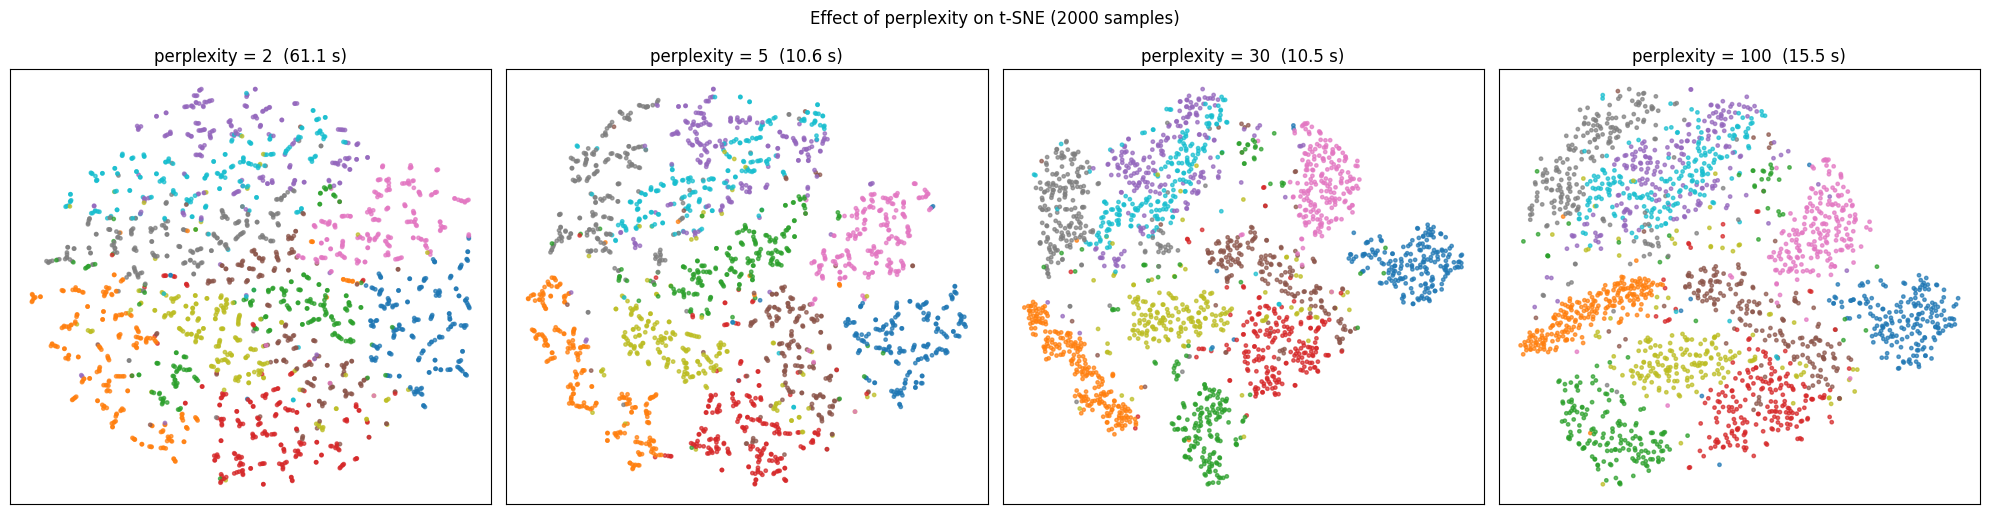

In [17]:
pca50_2k = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_2k)
perplexities = [2, 5, 30, 100]
fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))
for ax, perp in zip(axes, perplexities):
    t0 = time.time()
    Z = TSNE(n_components=2, perplexity=perp, init='pca', learning_rate='auto',
             random_state=RANDOM_STATE, n_jobs=-1).fit_transform(pca50_2k)
    plot_embedding(Z, y_2k, f'perplexity = {perp}  ({time.time() - t0:.1f} s)', ax=ax, s=6, annotate=False)
plt.suptitle('Effect of perplexity on t-SNE (2000 samples)')
plt.tight_layout()
plt.show()

<div dir="rtl">

## ۹. سایر روش‌های یادگیری منیفلد

| روش | ایده اصلی | چه چیزی را حفظ می‌کند؟ |
|---|---|---|
| **MDS** (Multidimensional Scaling) | نقاط را طوری در ۲ بعد می‌چیند که **فاصله‌های دوبه‌دو** تا حد ممکن حفظ شوند (کمینه کردن Stress) | فاصله‌های سراسری |
| **Isomap** | گراف k-نزدیک‌ترین همسایه می‌سازد، **فاصله ژئودزیک** (کوتاه‌ترین مسیر روی گراف) را حساب می‌کند و سپس MDS می‌زند | فاصله روی منیفلد |
| **LLE** (Locally Linear Embedding) | هر نقطه را به صورت **ترکیب خطی همسایه‌هایش** بازسازی می‌کند و همان وزن‌ها را در فضای کم‌بعد حفظ می‌کند | هندسه محلی |
| **Spectral Embedding** (Laplacian Eigenmaps) | از بردارهای ویژه **لاپلاسین گراف** شباهت استفاده می‌کند | همسایگی‌ها / خوشه‌ها |
| **t-SNE** | تطبیق توزیع احتمال همسایگی (بخش ۸) | همسایگی‌های محلی |
| **UMAP** (خارج از sklearn) | مبتنی بر توپولوژی و گراف فازی؛ شبیه t-SNE اما سریع‌تر و با حفظ بهتر ساختار کلی؛ `transform` دارد | محلی + تا حدی سراسری |

همه روش‌ها را روی **همان ۲۰۰۰ نمونه** اجرا می‌کنیم (برای روش‌های غیرخطی از ورودی PCA-50 استفاده می‌کنیم) و زمان اجرا را ثبت می‌کنیم.

</div>

In [18]:
methods = {
    'PCA':              (PCA(n_components=2, random_state=RANDOM_STATE), 'raw'),
    'TruncatedSVD':     (TruncatedSVD(n_components=2, random_state=RANDOM_STATE), 'raw'),
    'KernelPCA (RBF)':  (KernelPCA(n_components=2, kernel='rbf', gamma=0.01), 'raw'),
    'LDA (supervised)': (LinearDiscriminantAnalysis(n_components=2), 'raw'),
    'MDS':              (MDS(n_components=2, n_init=1, max_iter=300, random_state=RANDOM_STATE), 'pca50'),
    'Isomap':           (Isomap(n_neighbors=10, n_components=2), 'pca50'),
    'LLE (modified)':   (LocallyLinearEmbedding(n_neighbors=12, n_components=2, method='modified',
                                                random_state=RANDOM_STATE), 'pca50'),
    'Spectral':         (SpectralEmbedding(n_components=2, n_neighbors=10, random_state=RANDOM_STATE), 'pca50'),
    't-SNE':            (TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
                              random_state=RANDOM_STATE, n_jobs=-1), 'pca50'),
}

embeddings, times = {}, {}
for name, (model, inp) in methods.items():
    Xin = X_2k if inp == 'raw' else pca50_2k
    t0 = time.time()
    embeddings[name] = model.fit_transform(Xin, y_2k) if 'LDA' in name else model.fit_transform(Xin)
    times[name] = time.time() - t0
    print(f'{name:<18} {times[name]:6.2f} s')

try:                                   # optional: UMAP (pip install umap-learn)
    import umap
    t0 = time.time()
    embeddings['UMAP'] = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE).fit_transform(pca50_2k)
    times['UMAP'] = time.time() - t0
    print(f"{'UMAP':<18} {times['UMAP']:6.2f} s")
except ImportError:
    print('UMAP not installed -> skipped (install with: pip install umap-learn)')

PCA                  0.03 s
TruncatedSVD         0.02 s
KernelPCA (RBF)      0.13 s


LDA (supervised)     0.55 s


MDS                 40.00 s


Isomap               2.44 s


LLE (modified)       4.18 s


Spectral             0.35 s


t-SNE                9.25 s
UMAP not installed -> skipped (install with: pip install umap-learn)


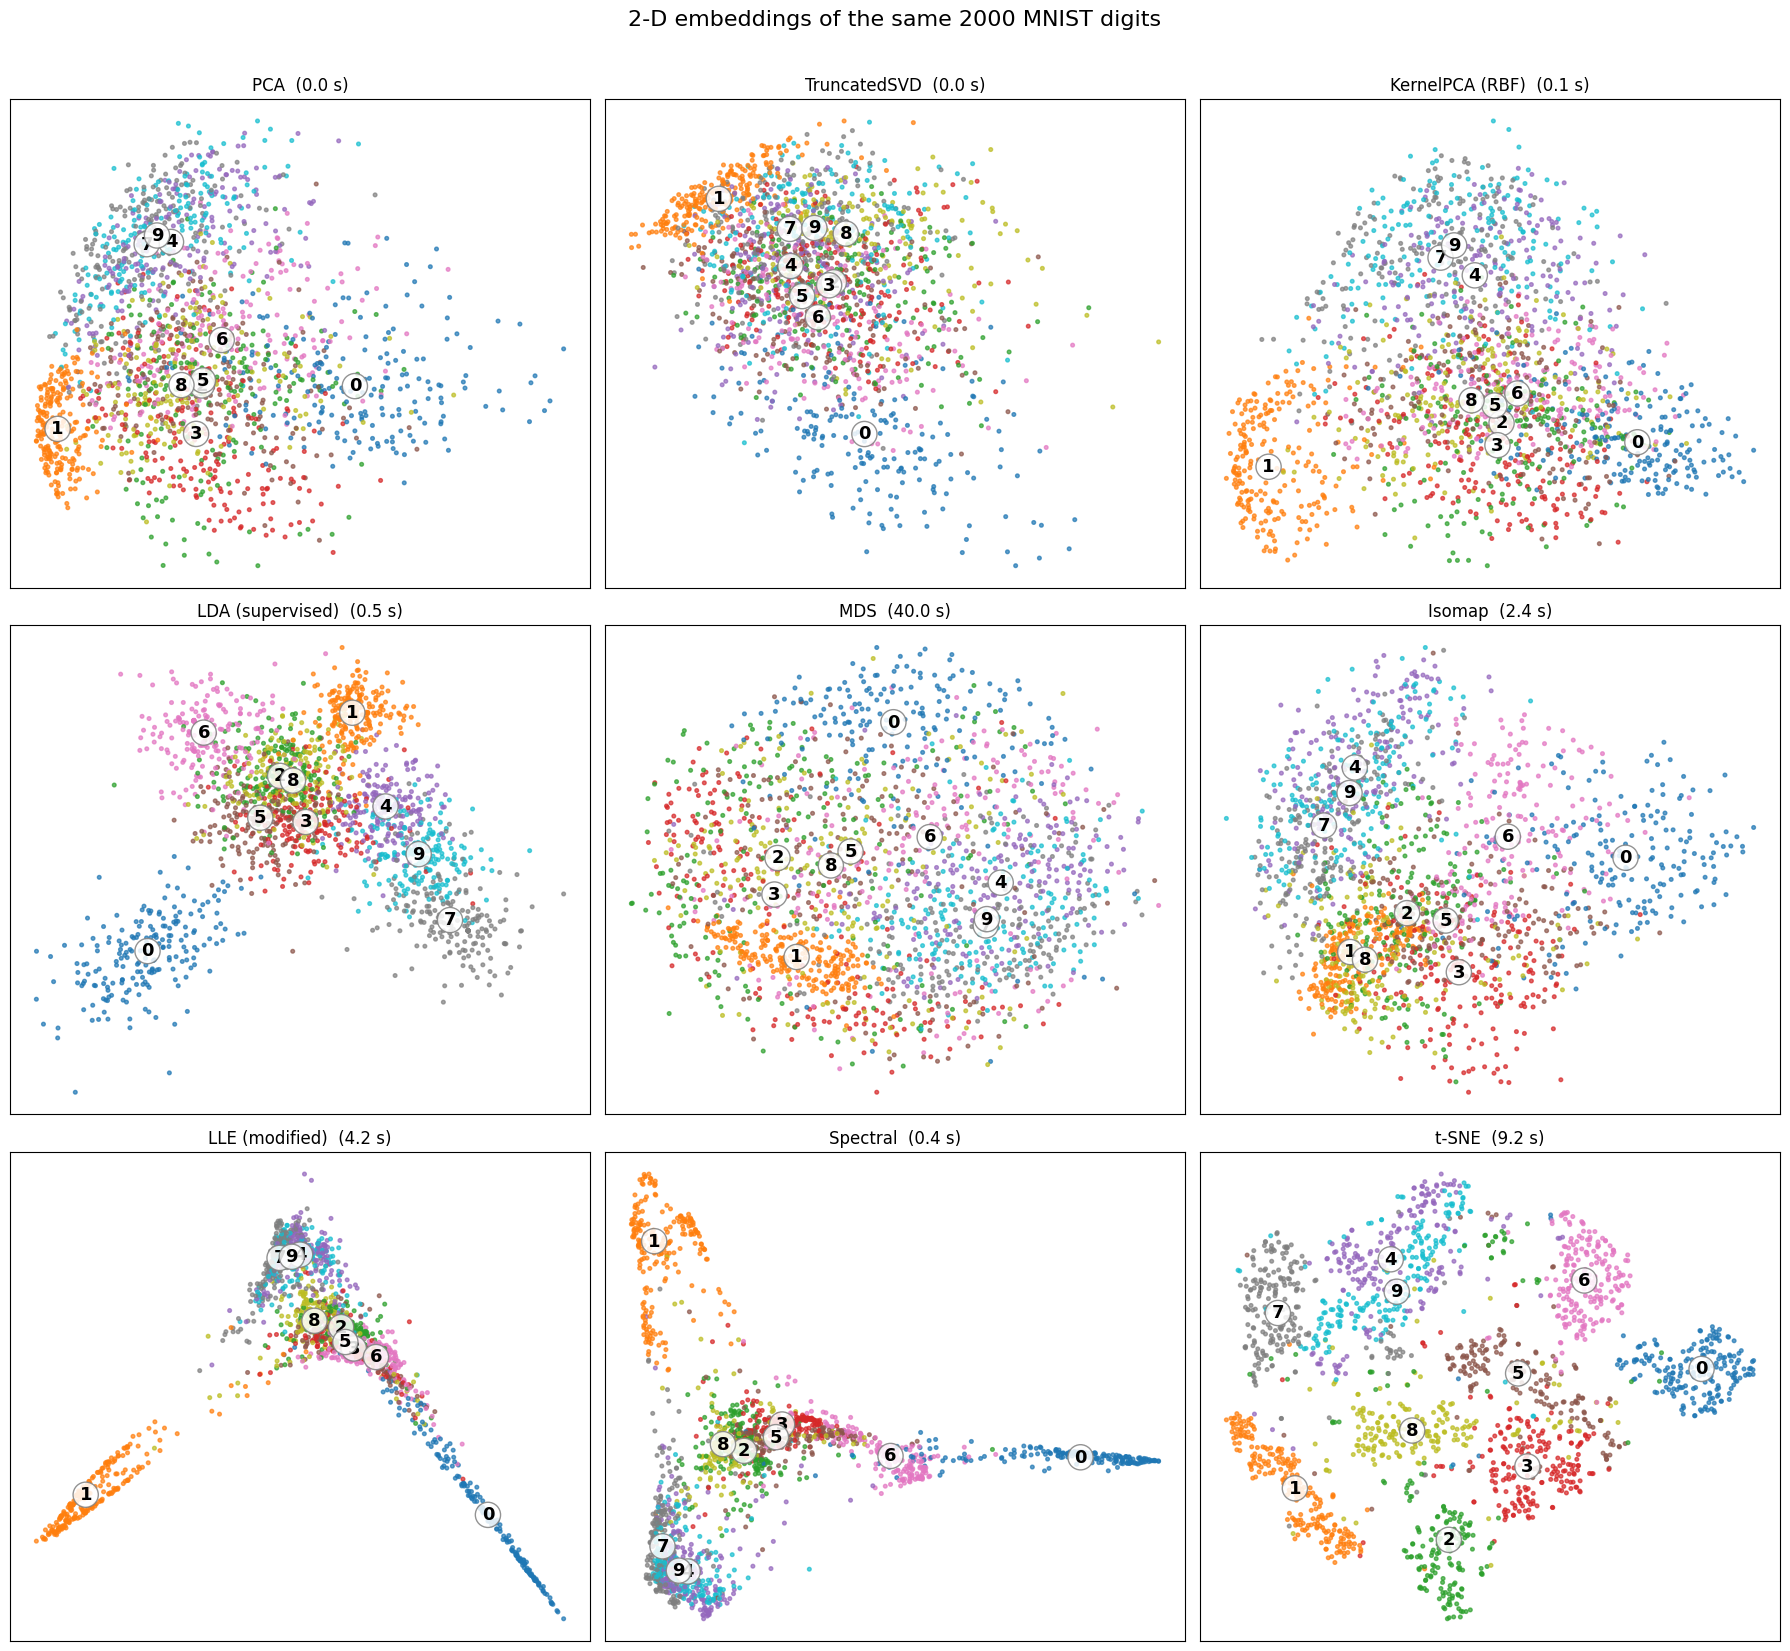

In [19]:
n = len(embeddings)
ncols = 3 if n <= 9 else 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.6 * nrows))
for ax, (name, Z) in zip(axes.ravel(), embeddings.items()):
    plot_embedding(Z, y_2k, f'{name}  ({times[name]:.1f} s)', ax=ax, s=7)
for ax in axes.ravel()[n:]:
    ax.axis('off')
plt.suptitle('2-D embeddings of the same 2000 MNIST digits', fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

<div dir="rtl">

## ۱۰. مقایسه کمّی روش‌ها

مقایسه بصری ذهنی است؛ بنابراین دو معیار کمّی هم حساب می‌کنیم:

1. **Trustworthiness (قابلیت اعتماد)** — `sklearn.manifold.trustworthiness`
   بررسی می‌کند آیا $k$ همسایه نزدیک هر نقطه در فضای کم‌بعد، واقعاً در فضای اصلی هم همسایه بوده‌اند یا نه. مقدار بین ۰ و ۱ است؛ ۱ یعنی ساختار محلی کاملاً حفظ شده:
$$T(k) = 1 - \frac{2}{nk(2n - 3k - 1)} \sum_{i=1}^{n} \sum_{j \in \mathcal{N}_i^k} \max(0, r(i,j) - k)$$
   که $r(i,j)$ رتبه نقطه $j$ در همسایگی نقطه $i$ در فضای اصلی است.

2. **دقت kNN در فضای ۲بعدی** — با 5-Fold CV یک طبقه‌بند kNN را روی مختصات دوبعدی آموزش می‌دهیم. اگر کلاس‌ها در نقشه جدا باشند، دقت بالا خواهد بود.

> یادآوری: LDA از برچسب‌ها استفاده کرده است، پس دقت kNN آن «تقلب» محسوب می‌شود و فقط برای مرجع است.

</div>

,trustworthiness,kNN_acc_2D,time_s
method,,,
t-SNE,0.9724,0.8980,9.2493
Spectral,0.8238,0.6560,0.3549
LLE (modified),0.7854,0.5825,4.1839
Isomap,0.7702,0.4580,2.4362
MDS,0.7631,0.3980,39.9962
PCA,0.7338,0.3830,0.0267
KernelPCA (RBF),0.7236,0.3775,0.1304
LDA (supervised),0.6936,0.6490,0.5472
TruncatedSVD,0.6923,0.3080,0.0232


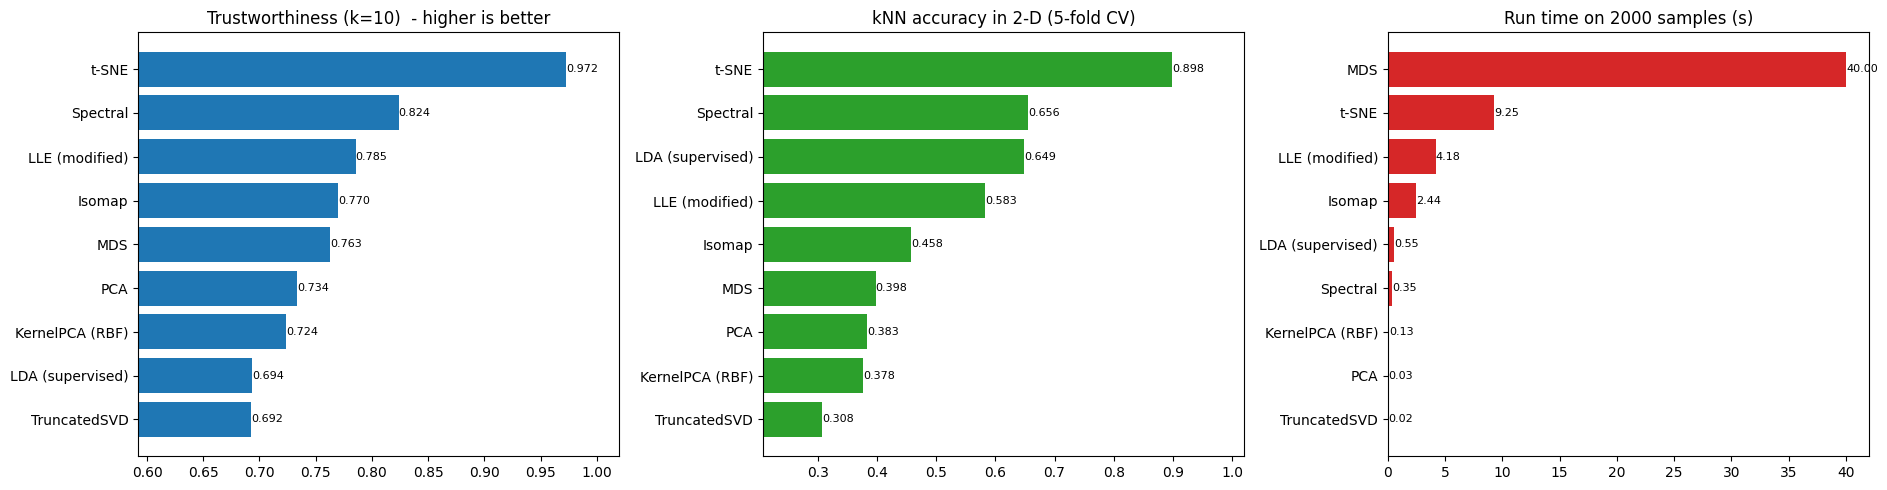

In [20]:
rows = []
for name, Z in embeddings.items():
    tw = trustworthiness(X_2k, Z, n_neighbors=10)
    knn_acc = cross_val_score(KNeighborsClassifier(n_neighbors=5), Z, y_2k, cv=5).mean()
    rows.append({'method': name, 'trustworthiness': tw, 'kNN_acc_2D': knn_acc, 'time_s': times[name]})
cmp_df = pd.DataFrame(rows).set_index('method').sort_values('trustworthiness', ascending=False)
display(cmp_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, col, color, title in [(axes[0], 'trustworthiness', 'tab:blue', 'Trustworthiness (k=10)  - higher is better'),
                              (axes[1], 'kNN_acc_2D', 'tab:green', 'kNN accuracy in 2-D (5-fold CV)'),
                              (axes[2], 'time_s', 'tab:red', 'Run time on 2000 samples (s)')]:
    s = cmp_df[col].sort_values()
    bars = ax.barh(s.index, s.values, color=color)
    ax.bar_label(bars, fmt='%.3f' if col != 'time_s' else '%.2f', fontsize=8)
    ax.set_title(title)
    if col != 'time_s':
        ax.set_xlim(max(0, s.min() - 0.1), 1.02)
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:**
- **t-SNE** (و UMAP در صورت نصب) بیشترین Trustworthiness و بهترین جداسازی کلاس‌ها را در ۲ بعد دارند؛ چون مستقیماً برای حفظ همسایگی‌ها بهینه می‌شوند.
- **روش‌های خطی** (PCA، SVD) سریع‌ترین هستند ولی در ۲ بعد اطلاعات کمی نگه می‌دارند.
- **Isomap** و **Spectral** جایی بین این دو قرار می‌گیرند.
- **MDS** سعی می‌کند *همه* فاصله‌ها را حفظ کند که در ۲ بعد غیرممکن است؛ بنابراین ساختار محلی را فدا می‌کند.
- **LDA** به خاطر استفاده از برچسب‌ها در ۲ بعد جداسازی بسیار بهتری از PCA دارد (دقت kNN بالاتر)، اما Trustworthiness آن پایین است چون هدفش حفظ همسایگی‌ها نیست؛ ضمناً حداکثر ۹ بعد می‌دهد و فقط وقتی برچسب داریم قابل استفاده است.

</div>

<div dir="rtl">

## ۱۱. کاهش ابعاد به عنوان پیش‌پردازش برای طبقه‌بندی

کاربرد عملی مهم PCA: **کاهش ابعاد قبل از آموزش مدل** برای افزایش سرعت و کاهش نویز. با یک `Pipeline` شامل `PCA` و طبقه‌بند **kNN** (که به‌شدت از ابعاد بالا رنج می‌برد) دقت و زمان را برای تعداد مؤلفه‌های مختلف اندازه می‌گیریم.

- آموزش: ۲۰۰۰۰ نمونه از داده آموزش
- آزمون: کل ۱۰۰۰۰ نمونه آزمون
- مقایسه با kNN روی داده خام ۷۸۴ بعدی و روی خروجی LDA (۹ بعد)

> چرا t-SNE را اینجا امتحان نمی‌کنیم؟ چون t-SNE متد `transform` برای داده جدید ندارد.

</div>

PCA-2    + kNN: acc=0.4053  time=1.5s


PCA-5    + kNN: acc=0.7165  time=1.7s


PCA-10   + kNN: acc=0.9134  time=2.4s


PCA-20   + kNN: acc=0.9573  time=1.4s


PCA-30   + kNN: acc=0.9654  time=1.6s


PCA-50   + kNN: acc=0.9665  time=1.8s


PCA-100  + kNN: acc=0.9599  time=2.2s


PCA-200  + kNN: acc=0.9580  time=2.9s


raw 784  + kNN: acc=0.9558  time=8.6s


LDA-9    + kNN: acc=0.9004  time=7.3s


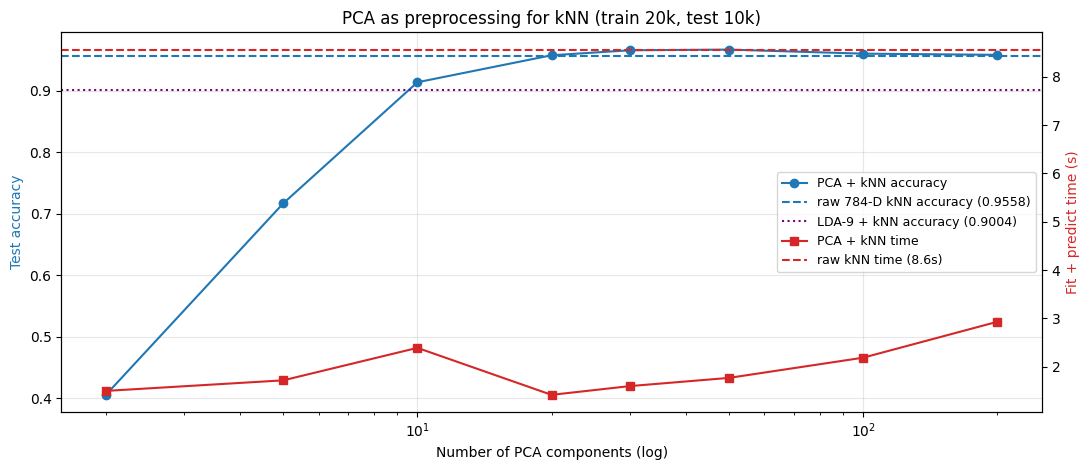

In [21]:
X_20k, y_20k = stratified_subset(X_train, y_train, 20000)
n_list = [2, 5, 10, 20, 30, 50, 100, 200]
res = []
for k in n_list:
    pipe = make_pipeline(PCA(n_components=k, random_state=RANDOM_STATE), KNeighborsClassifier(n_neighbors=3, n_jobs=-1))
    t0 = time.time(); pipe.fit(X_20k, y_20k); acc = pipe.score(X_test, y_test); dt = time.time() - t0
    res.append({'n_components': k, 'accuracy': acc, 'time_s': dt})
    print(f'PCA-{k:<4} + kNN: acc={acc:.4f}  time={dt:.1f}s')

t0 = time.time()
raw_acc = KNeighborsClassifier(n_neighbors=3, n_jobs=-1).fit(X_20k, y_20k).score(X_test, y_test)
raw_time = time.time() - t0
print(f'raw 784  + kNN: acc={raw_acc:.4f}  time={raw_time:.1f}s')
lda_pipe = make_pipeline(LinearDiscriminantAnalysis(n_components=9), KNeighborsClassifier(n_neighbors=3, n_jobs=-1))
t0 = time.time(); lda_acc = lda_pipe.fit(X_20k, y_20k).score(X_test, y_test); lda_time = time.time() - t0
print(f'LDA-9    + kNN: acc={lda_acc:.4f}  time={lda_time:.1f}s')
res_df = pd.DataFrame(res)

fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(res_df['n_components'], res_df['accuracy'], 'o-', color='tab:blue', label='PCA + kNN accuracy')
ax1.axhline(raw_acc, color='tab:blue', ls='--', label=f'raw 784-D kNN accuracy ({raw_acc:.4f})')
ax1.axhline(lda_acc, color='purple', ls=':', label=f'LDA-9 + kNN accuracy ({lda_acc:.4f})')
ax1.set_xscale('log'); ax1.set_xlabel('Number of PCA components (log)'); ax1.set_ylabel('Test accuracy', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(res_df['n_components'], res_df['time_s'], 's-', color='tab:red', label='PCA + kNN time')
ax2.axhline(raw_time, color='tab:red', ls='--', label=f'raw kNN time ({raw_time:.1f}s)')
ax2.set_ylabel('Fit + predict time (s)', color='tab:red')
h = ax1.get_legend_handles_labels(); h2 = ax2.get_legend_handles_labels()
ax1.legend(h[0] + h2[0], h[1] + h2[1], loc='center right', fontsize=9)
ax1.grid(alpha=0.3)
plt.title('PCA as preprocessing for kNN (train 20k, test 10k)')
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:** با حدود ۳۰ تا ۵۰ مؤلفه PCA، دقت kNN حتی **بیشتر از داده خام** می‌شود (چون PCA نویز و ابعاد بی‌اهمیت را حذف می‌کند) و زمان اجرا هم به مراتب کمتر است. با تعداد مؤلفه خیلی کم (۲ یا ۵)، اطلاعات لازم از دست می‌رود.

</div>

<div dir="rtl">

## ۱۲. جمع‌بندی و جدول مقایسه نهایی

| روش | نوع | نظارت | حفظ ساختار | `transform` داده جدید | مقیاس‌پذیری | کاربرد اصلی |
|---|---|---|---|---|---|---|
| **PCA** | خطی | ندارد | سراسری (واریانس) | ✅ | عالی | فشرده‌سازی، حذف نویز، پیش‌پردازش |
| **TruncatedSVD** | خطی | ندارد | سراسری | ✅ | عالی (اسپارس) | متن (LSA)، ماتریس‌های اسپارس بزرگ |
| **IncrementalPCA** | خطی | ندارد | سراسری | ✅ | داده بزرگ‌تر از حافظه | Big Data |
| **Kernel PCA** | غیرخطی | ندارد | بسته به کرنل | ✅ | ضعیف $O(n^2)$ | ساختارهای غیرخطی در داده کوچک |
| **LDA** | خطی | **دارد** | جداسازی کلاس‌ها | ✅ | عالی | پیش‌پردازش طبقه‌بندی (حداکثر C-1 بعد) |
| **NMF** | خطی | ندارد | اجزای نامنفی | ✅ | خوب | Topic Modeling، تفسیرپذیری |
| **ICA** | خطی | ندارد | استقلال آماری | ✅ | خوب | جداسازی منابع سیگنال |
| **MDS** | غیرخطی | ندارد | فاصله‌های سراسری | ❌ | ضعیف | مصورسازی ماتریس فاصله |
| **Isomap** | غیرخطی | ندارد | فاصله ژئودزیک | ✅ | متوسط | منیفلدهای پیوسته (مثل Swiss roll) |
| **LLE** | غیرخطی | ندارد | هندسه محلی | ✅ | متوسط | منیفلدهای هموار |
| **Spectral** | غیرخطی | ندارد | همسایگی گراف | ❌ | متوسط | خوشه‌بندی طیفی |
| **t-SNE** | غیرخطی | ندارد | همسایگی محلی | ❌ | متوسط ($O(n\log n)$) | **مصورسازی** |
| **UMAP** | غیرخطی | ندارد | محلی + تا حدی سراسری | ✅ | خوب | مصورسازی و پیش‌پردازش |

### راهنمای انتخاب
- **می‌خواهید داده را فشرده کنید یا مدل سریع‌تر شود؟** ← PCA (یا TruncatedSVD برای داده اسپارس)
- **برچسب دارید و هدف طبقه‌بندی است؟** ← LDA را هم امتحان کنید
- **فقط می‌خواهید داده را ببینید؟** ← PCA-50 سپس t-SNE (یا UMAP)
- **مؤلفه‌های قابل تفسیر می‌خواهید؟** ← NMF
- **همیشه اول PCA را امتحان کنید**؛ ساده، سریع و قابل اعتماد است.

### تمرین‌ها
1. t-SNE را روی ۱۰۰۰۰ نمونه اجرا کنید و زمان را با ۵۰۰۰ نمونه مقایسه کنید.
2. پارامتر `n_neighbors` را در Isomap بین ۵ تا ۵۰ تغییر دهید و Trustworthiness را رسم کنید.
3. با `PCA(n_components=0.9, whiten=True)` داده را پیش‌پردازش کنید و یک `MLPClassifier` آموزش دهید. سرعت و دقت را با داده خام مقایسه کنید.
4. `umap-learn` را نصب کنید و آن را با t-SNE روی ۵۰۰۰ نمونه مقایسه کنید.
5. بازسازی Kernel PCA را با `fit_inverse_transform=True` برای حذف نویز تصاویر امتحان کنید (نویز گاوسی به تصاویر اضافه کنید).

</div>